# BedMachine Region to Pattern Figures

This notebook loads a locally placed BedMachine Antarctica file, extracts a
small x/y subset, computes an ice draft field and floating-ice mask, then runs
the synthetic Phase 3 channel detector on that subset.


In [66]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from scipy.ndimage import binary_erosion
from skimage.measure import label


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in (current, *current.parents):
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing pyproject.toml")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ioblp.data import get_data_dirs, load_bedmachine_default
from ioblp.patterns import (
    channelness_metric,
    compute_hessian,
    compute_orientation,
    extract_channels,
    hessian_eigenvalues,
    skeletonize_mask,
    smooth_field,
)
from ioblp.preprocess import compute_ice_draft, get_floating_mask, subset_xy


In [67]:
# Adjust these bounds if the default subset does not show enough floating ice.
X_MIN = -500_000
X_MAX = 500_000
Y_MIN = -1_200_000
Y_MAX = -400_000
SIGMA = 6.0
EDGE_BUFFER = 5
THRESHOLD_QUANTILE = 0.995


In [68]:
data_dirs = get_data_dirs()
figures_dir = PROJECT_ROOT / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

ds = load_bedmachine_default()
region = subset_xy(ds, X_MIN, X_MAX, Y_MIN, Y_MAX)
draft = compute_ice_draft(region)
floating_mask = get_floating_mask(region)
floating_interior = floating_mask.copy(
    data=binary_erosion(np.asarray(floating_mask, dtype=bool), iterations=EDGE_BUFFER)
)

print(f"Loaded dataset from: {(data_dirs['raw'] / 'bedmachine_antarctica.nc').relative_to(PROJECT_ROOT)}")
print(f"Subset shape: {draft.shape}")
print(f"EDGE_BUFFER: {EDGE_BUFFER}")
print(f"Floating cells: {int(floating_mask.sum())}")
print(f"Floating interior cells: {int(floating_interior.sum())}")


Loaded dataset from: data/raw/bedmachine_antarctica.nc
Subset shape: (1601, 2001)
EDGE_BUFFER: 5
Floating cells: 1617779
Floating interior cells: 1562323


In [69]:
draft_for_detection = draft.where(floating_interior)
interior_values = np.asarray(draft.where(floating_interior), dtype=float)
if np.isnan(interior_values).all():
    raise ValueError("Floating interior is empty. Reduce EDGE_BUFFER or change the subset bounds.")
interior_fill = float(np.nanmean(interior_values))
draft_values = np.asarray(draft_for_detection.fillna(interior_fill), dtype=float)
smoothed = smooth_field(draft_values, sigma=SIGMA)
dxx, dyy, dxy = compute_hessian(smoothed)
lambda1, lambda2 = hessian_eigenvalues(dxx, dyy, dxy)
metric = channelness_metric(lambda1, lambda2)

interior_mask_values = np.asarray(floating_interior, dtype=bool)
positive_metric = metric[(metric > 0) & interior_mask_values]
if positive_metric.size == 0:
    threshold = 0.0
else:
    threshold = float(np.quantile(positive_metric, THRESHOLD_QUANTILE))

channels = extract_channels(metric, threshold=threshold)
channels &= interior_mask_values
skeleton = skeletonize_mask(channels)

print(f"Threshold used: {threshold:.6f}")
print(f"Detected channel pixels: {int(channels.sum())}")
print(f"Skeleton pixels: {int(skeleton.sum())}")


Threshold used: 1.381825
Detected channel pixels: 6140
Skeleton pixels: 994


In [70]:
# Quantitative Diagnostics

import numpy as np

detected = channels

floating_fraction = floating_mask.sum() / floating_mask.size

print("=== Diagnostics ===")
print("Floating fraction:", float(floating_fraction))
print("Threshold used:", float(threshold))
print("Detected pixels:", int(detected.sum()))
print("Skeleton pixels:", int(skeleton.sum()))

# Orientation from the same field used for detection smoothing if available.
# If your notebook variable is named `smoothed`, use it; otherwise use the field you pass into Hessian.
orientation = compute_orientation(smoothed)
skeleton_orientations = orientation[skeleton]

labels = label(skeleton, connectivity=2)
n_components = int(labels.max())
print("Number of channel components:", n_components)

if n_components == 0:
    lengths_pixels = np.array([], dtype=float)
    print("Median length (pixels): 0.0")
    print("Mean length (pixels): 0.0")
else:
    lengths_pixels = np.array([np.sum(labels == i) for i in range(1, n_components + 1)], dtype=float)
    print("Median length (pixels):", float(np.median(lengths_pixels)))
    print("Mean length (pixels):", float(np.mean(lengths_pixels)))


=== Diagnostics ===
Floating fraction: 0.5049876685642188
Threshold used: 1.3818251347407193
Detected pixels: 6140
Skeleton pixels: 994
Number of channel components: 56
Median length (pixels): 7.0
Mean length (pixels): 17.75


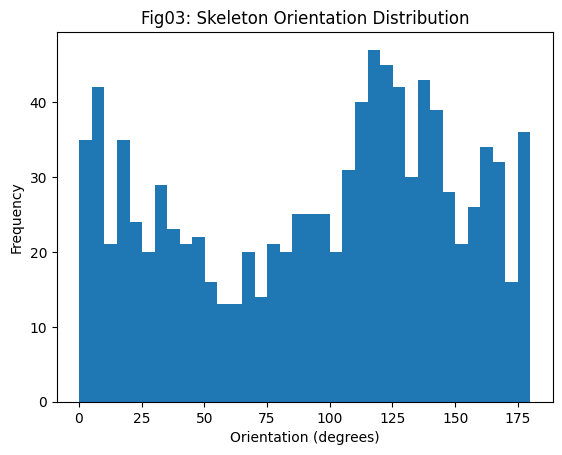

In [71]:
import matplotlib.pyplot as plt

plt.figure()
if skeleton_orientations.size:
    plt.hist(skeleton_orientations, bins=36)
plt.xlabel("Orientation (degrees)")
plt.ylabel("Frequency")
plt.title("Fig03: Skeleton Orientation Distribution")
plt.savefig(figures_dir / "fig03_orientation_hist.png", dpi=300, bbox_inches="tight")
plt.show()


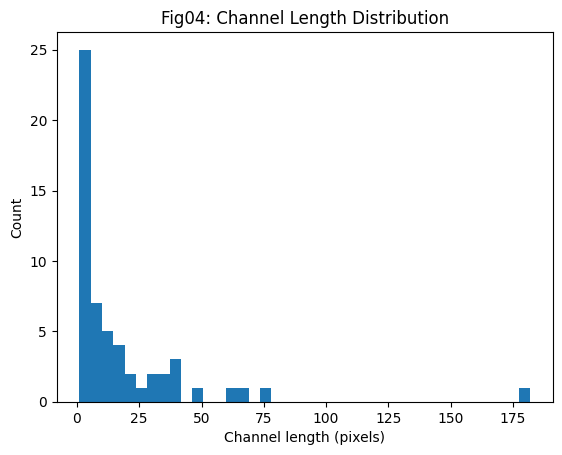

In [72]:
plt.figure()
if lengths_pixels.size:
    plt.hist(lengths_pixels, bins=40)
plt.xlabel("Channel length (pixels)")
plt.ylabel("Count")
plt.title("Fig04: Channel Length Distribution")
plt.savefig(figures_dir / "fig04_channel_lengths.png", dpi=300, bbox_inches="tight")
plt.show()


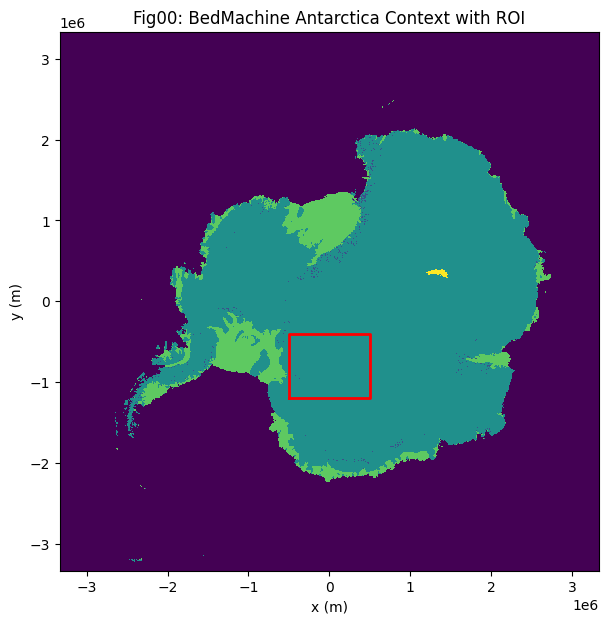

In [73]:
# Fig00: Context Map (BedMachine Antarctica + ROI box)

import xarray as xr

context_path = PROJECT_ROOT / "data" / "raw" / "bedmachine_antarctica.nc"
with xr.open_dataset(context_path, engine="netcdf4") as context_ds:
    floating = context_ds["mask"] == 3
    step = 10
    floating_coarse = floating[::step, ::step].load()
    x_coarse = context_ds["x"][::step].load()
    y_coarse = context_ds["y"][::step].load()

extent = [float(x_coarse.min()), float(x_coarse.max()), float(y_coarse.min()), float(y_coarse.max())]
xs = [X_MIN, X_MAX, X_MAX, X_MIN, X_MIN]
ys = [Y_MIN, Y_MIN, Y_MAX, Y_MAX, Y_MIN]

plt.figure(figsize=(9, 7))
plt.imshow(floating_coarse, extent=extent, origin="lower", cmap="gray")
plt.plot(xs, ys, color="red", linewidth=2)
plt.title("Fig00: Floating Ice (BedMachine) with ROI")
plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.savefig(figures_dir / "fig00_region_context.png", dpi=300, bbox_inches="tight")
plt.show()


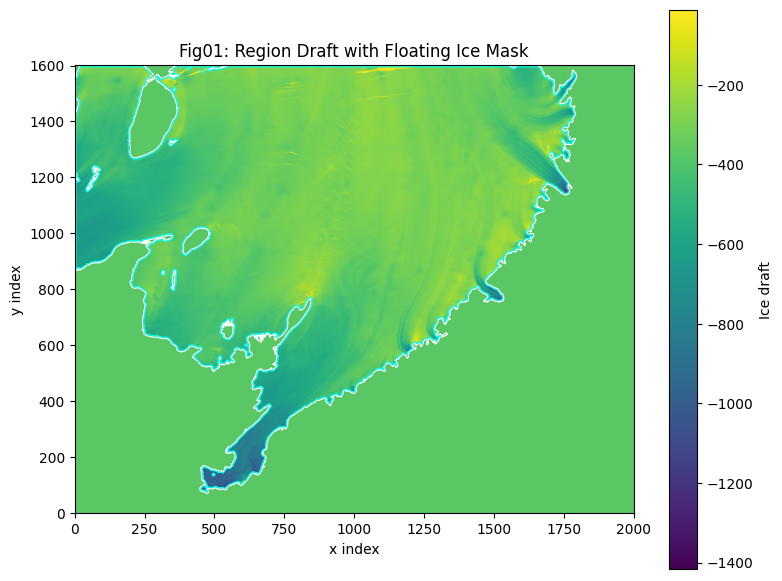

Saved figures/fig01_region_draft.png


In [74]:
fig01_path = figures_dir / "fig01_region_draft.png"

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(draft_values, origin="lower", cmap="viridis")
ax.contour(np.asarray(floating_mask, dtype=int), levels=[0.5], colors="white", linewidths=0.8)
ax.contour(np.asarray(floating_interior, dtype=int), levels=[0.5], colors="cyan", linewidths=0.8)
ax.set_title("Fig01: Region Draft with Floating Ice Mask")
ax.set_xlabel("x index")
ax.set_ylabel("y index")
fig.colorbar(im, ax=ax, label="Ice draft")
fig.tight_layout()
fig.savefig(fig01_path, dpi=150)
plt.show()
plt.close(fig)

print(f"Saved {fig01_path.relative_to(PROJECT_ROOT)}")


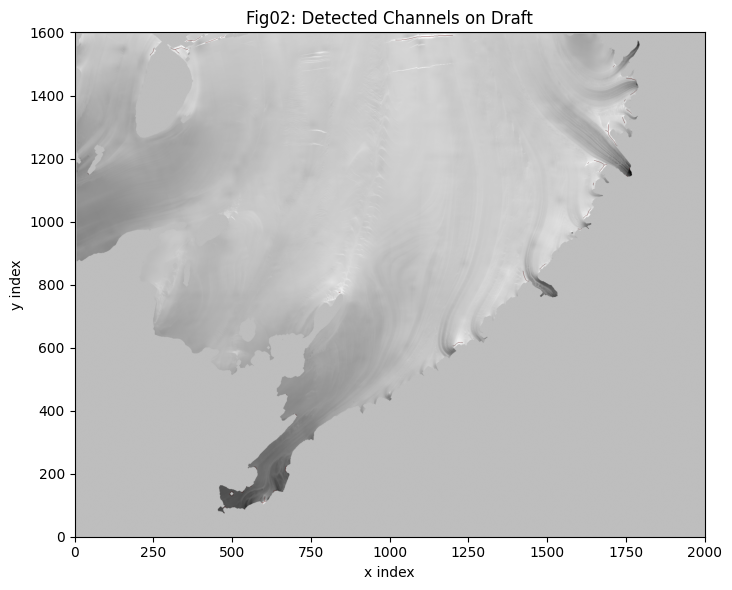

Saved figures/fig02_channels_overlay.png


In [75]:
fig02_path = figures_dir / "fig02_channels_overlay.png"

fig, ax = plt.subplots(figsize=(8, 6))
ax.imshow(draft_values, origin="lower", cmap="gray")
overlay = np.ma.masked_where(~skeleton, skeleton)
ax.imshow(overlay, origin="lower", cmap="autumn", alpha=0.9)
ax.set_title("Fig02: Detected Channels on Draft")
ax.set_xlabel("x index")
ax.set_ylabel("y index")
fig.tight_layout()
fig.savefig(fig02_path, dpi=800)
plt.show()
plt.close(fig)

print(f"Saved {fig02_path.relative_to(PROJECT_ROOT)}")
